# What underlaying statistics predict high offensive production among NHL players? (Regression Analysis)

Made by: Agustin, Alvaro, Catherine, Iisakki, Irem

Business question: An NHL front office wants to identify which measurable player attributes best predict total scoring output (Points). By understanding these drivers, the team can make smarter roster decisions — targeting undervalued players whose underlying stats suggest they will produce more points.

Data: 610 NHL skaters from the 2024-25 season (MoneyPuck.com), with 86 columns covering shooting, ice time, on-ice impact, and advanced metrics. Only players with minimum 500 minutes of ice time were selected for this analysis in order to have a more fair comparison between players.

Target Variable (y): Points = total goals + primary assists + secondary assists. The most widely used measure of overall offensive player performance.



Step 1: Importing libraries.

First, we import the necessary Python tools. These libraries allow us to handle data, perform math, create charts, and run our regression models.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import statsmodels.api as sm

Step 2: Loading our dataset. 

We load our NHL player dataset. A key step here is calculating our target variable: Points. In hockey, a player's total points are the sum of their Goals, Primary Assists, and Secondary Assists.

Source of the dataset: MoneyPuck.com

In [68]:
df_raw = pd.read_csv('nhl_player_stats.csv')

# Calculating the target variable
df_raw['Points'] = df_raw['Goals'] + df_raw['Primary_Assists'] + df_raw['Secondary_Assists']
df_raw

,Rank,Team,Name,Pos,Games_Played,Icetime_Minutes,Expected_Goals,Goals,Assists,Points,...,Share_xGoals_From_Rebounds_Shots,xGoals_From_Non_Rebounds,xGoals_Of_Expected_Rebounds,Created_xGoals,Created_xGoals_Minus_Actual,Goals_Repeated,Expected_Goals_Repeated,Shooting_Talent_Above_Average,Shooting_Talent_Adj_Expected_Goals,Goals_Above_Shooting_Talent
0,1,Anaheim Ducks,Leo Carlsson,C,76,1234,17.2,20,24,44,...,25.1,12.9,2.0,14.9,-2.3,20,17.2,0.1,17.2,2.8
1,2,Anaheim Ducks,Frank Vatrano,R,81,1421,28.9,21,24,45,...,21.1,22.8,3.5,26.3,-2.6,21,28.9,10.4,31.9,-10.9
2,3,Anaheim Ducks,Drew Helleson,D,56,915,2.4,4,9,13,...,20.7,1.9,0.7,2.6,0.2,4,2.4,0.0,2.4,1.6
3,4,Anaheim Ducks,Jackson LaCombe,D,75,1672,10.3,14,29,43,...,27.9,7.4,2.1,9.5,-0.8,14,10.3,-19.0,8.3,5.7
4,5,Anaheim Ducks,Trevor Zegras,C,57,971,11.6,12,20,32,...,25.4,8.7,1.7,10.3,-1.3,12,11.6,19.4,13.9,-1.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,606,Winnipeg Jets,Alex Iafallo,L,82,1089,14.5,15,16,31,...,30.4,10.1,1.8,11.9,-2.6,15,14.5,-4.1,13.9,1.1
606,607,Winnipeg Jets,Colin Miller,D,60,871,2.9,4,11,15,...,11.0,2.6,0.9,3.5,0.6,4,2.9,6.0,3.1,0.9
607,608,Winnipeg Jets,Neal Pionk,D,69,1522,5.3,10,29,39,...,8.9,4.8,1.7,6.5,1.2,10,5.3,-5.5,5.0,5.0
608,609,Winnipeg Jets,Mason Appleton,C,71,1053,10.9,10,12,22,...,22.0,8.5,1.4,9.9,-1.0,10,10.9,-5.8,10.3,-0.3


Step 3: Feature selection

We ended up in the final set of features through a lot of trial and error, some of which is scattered around multiple notebooks and unfortunately didn't make it in the final version. However, in order to make feature selection as clear as possible, here the dropped features are grouped and docuemented in a way that it is understandable how many features were dropped and for which reasons. 

Some features, for example 'On_Ice_Corsi_Pct' was dropped but later brought back, because we realized it could be used as a valuable control variable to take into account the effect of players playing in teams and lines that do not produce equal amount of offense. 

In [69]:
initial_count = df_raw.shape[1]
print(f"Total starting columns: {initial_count}")

# 1. GROUP: Identifiers and Target Leakage
# We remove 'Rank', 'Name', and 'Team' as they aren't predictive. 
# We also remove Goals and Assists because they mathematically sum to our target.
leakage_drop = ['Rank', 'Name', 'Team', 'Goals', 'Assists', 'Primary_Assists', 'Secondary_Assists']
df_step1 = df_raw.drop(columns=leakage_drop)
print(f"Step 1: Removed Identifiers & Leakage. Features: {initial_count} -> {df_step1.shape[1]}")

# 2. GROUP: Redundant Rate Statistics
# Since we include total Icetime, keeping 'Per 60' rates adds redundant math (multicollinearity).
rates_drop = [col for col in df_step1.columns if '_Per_60' in col or '_Per_Game' in col or 'Points_Per_60' in col]
df_step2 = df_step1.drop(columns=rates_drop)
print(f"Step 2: Removed Redundant Rates/Averages. Features: {df_step1.shape[1]} -> {df_step2.shape[1]}")

# 3. GROUP: Near-Duplicate Advanced Metrics 
# MoneyPuck provides many variants of xG and Rebound stats (e.g. Flurry Adjusted, Score Adjusted).
# These are highly correlated and confuse the model.
duplicates_drop = [col for col in df_step2.columns if 'Expected' in col or 'xGoals' in col or 'Rebounds' in col]
# We remove these now, but we will selectively bring back 'On_Ice_Corsi_Pct' in the next step as a control.
df_step3 = df_step2.drop(columns=duplicates_drop)
print(f"Step 3: Removed Advanced Metric Variations. Features: {df_step2.shape[1]} -> {df_step3.shape[1]}")

# 4. GROUP: Domain Expertise & Final Selection
# Here we narrow the list down to our 6 explanatory skills and 4 environment controls.
explanatory = ['Faceoff_Win_Pct', 'Takeaways', 'Giveaways', 'Shot_Attempts', 
               'Shooting_Pct_On_Unblocked', 'PIM_Drawn']
controls = ['Icetime_Minutes', 'Pos', 'Pct_Shift_Starts_Offensive_Zone', 'On_Ice_Corsi_Pct']

# Final dataframe construction
final_features = explanatory + controls + ['Points']
df_final = df_raw[final_features].dropna()

print(f"Step 4: Applied Domain Expertise Filter. Final Feature Count: {len(final_features) - 1}")

Total starting columns: 86
Step 1: Removed Identifiers & Leakage. Features: 86 -> 79
Step 2: Removed Redundant Rates/Averages. Features: 79 -> 63
Step 3: Removed Advanced Metric Variations. Features: 63 -> 36
Step 4: Applied Domain Expertise Filter. Final Feature Count: 10


Step 4: Encoding

As we have a categorical variable 'Pos' (player position) in our final dataset, we convert these into "dummy" variables ('C', 'D', 'L', or 'R' ). We use Center (C) as our baseline, so all other results are compared against a typical Center.

In [70]:
# Convert Position into numerical columns
df_final = pd.get_dummies(df_final, columns=['Pos'], drop_first=True)

# Save the names of all our predictors for later use
all_features = [col for col in df_final.columns if col != 'Points']

Step 5: Train/Test split

To ensure our model is reliable, we split our data into two groups: a Training Set (80%) and a Testing Set (20%). We are using this split to compare two different approaches: 

OLS (Standard Regression): This is our baseline. It doesn't "learn" or adapt, it  finds the unique mathematical line that best fits the training data. By running it on the test data, we can see if we overfit the model or by comparing train and test r2.

Lasso (Adaptive Regression): Lasso "learns" during training by identifying which variables are truly important and shrinking the unimportant ones to zero. Comparing the performance (r2) of both models across both datasets tells us if our results are stable or if we are just seeing patterns in noise.

In [71]:
X = df_final[all_features]
y = df_final['Points']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Step 6: Training and running the models (OLS and Lasso separately)

Now, we train the Lasso model. We use a Standard Scaler first, which is normalizes the data so that a stat like Ice Time (measured in minutes) can be compared fairly against Shooting Percentage (measured in decimals).

For the Lasso model, we use a technique called K-Fold Cross-Validation. This means the model essentially runs several mini-tests on different parts of the training data to find the most accurate "penalty" to apply to the variables.

In [72]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=all_features)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=all_features)

# Adding a constant for the OLS model
X_train_sm = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train.values, X_train_sm).fit()

# Running Lasso with 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lasso_results = LassoCV(cv=kf, random_state=42).fit(X_train_scaled, y_train)

Step 8: Results

We now extract the final numbers. We will look at how much of the scoring variance we explained r2 and which specific skills had the most significant impact on a player's points.

--- MODEL PERFORMANCE SUMMARY ---
                         Metric  OLS Model  Lasso Model
     Train R-Squared (Accuracy)   0.871794     0.871670
Test R-Squared (Generalization)   0.859823     0.860058

--- FEATURE IMPACT & SIGNIFICANCE ---
                                                         Feature  \
Shot_Attempts                                      Shot_Attempts   
Shooting_Pct_On_Unblocked              Shooting_Pct_On_Unblocked   
Pct_Shift_Starts_Offensive_Zone  Pct_Shift_Starts_Offensive_Zone   
Giveaways                                              Giveaways   
Icetime_Minutes                                  Icetime_Minutes   
Takeaways                                              Takeaways   
PIM_Drawn                                              PIM_Drawn   
On_Ice_Corsi_Pct                                On_Ice_Corsi_Pct   
Faceoff_Win_Pct                                  Faceoff_Win_Pct   
Pos_R                                                      Pos_R   
Pos_L      

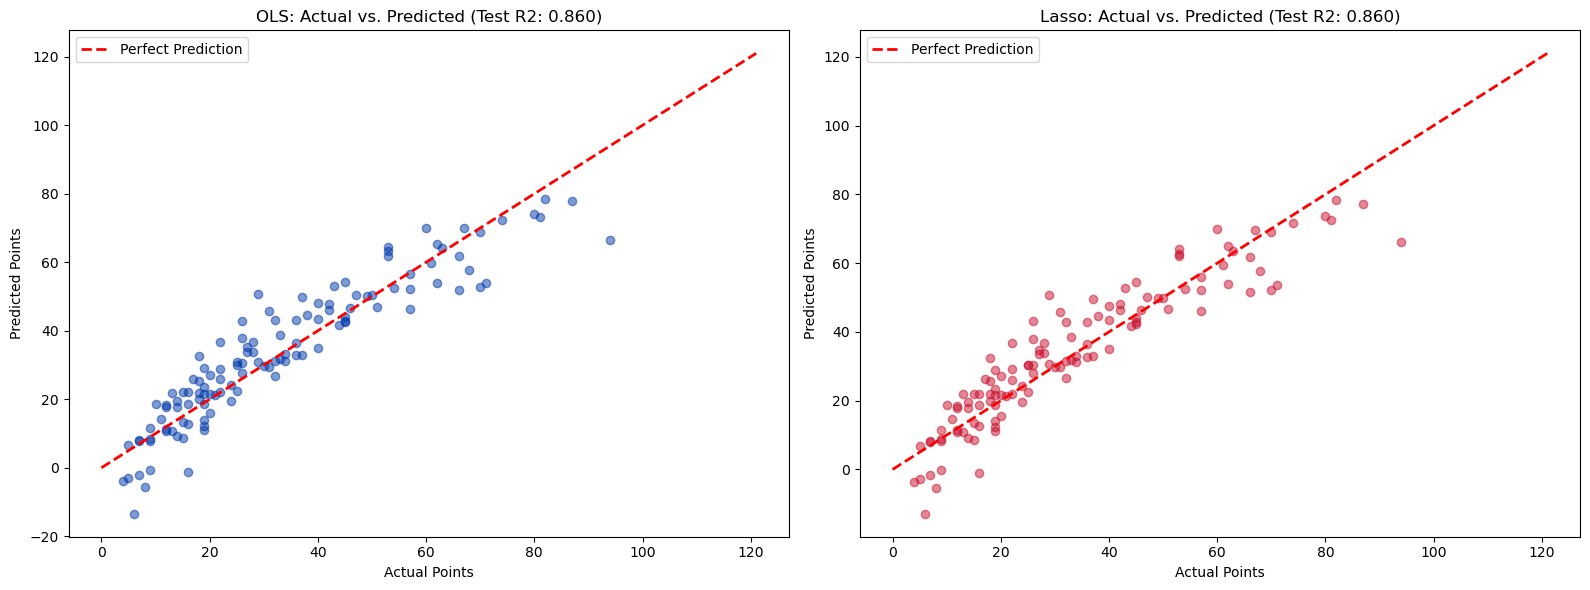

In [73]:
# 1. Calculate Squared R2 for Train and Test sets
ols_train_r2 = ols_model.rsquared
ols_test_r2 = r2_score(y_test, ols_model.predict(sm.add_constant(X_test_scaled)))

lasso_train_r2 = r2_score(y_train, lasso_results.predict(X_train_scaled))
lasso_test_r2 = r2_score(y_test, lasso_results.predict(X_test_scaled))

# 2. Display Accuracy Comparison Table
performance_df = pd.DataFrame({
    'Metric': ['Train R-Squared (Accuracy)', 'Test R-Squared (Generalization)'],
    'OLS Model': [ols_train_r2, ols_test_r2],
    'Lasso Model': [lasso_train_r2, lasso_test_r2]
})
print("--- MODEL PERFORMANCE SUMMARY ---")
print(performance_df.to_string(index=False))

# 3. Build Detailed Results Table
results_df = pd.DataFrame({
    'Feature': all_features,
    'OLS Coefficient': ols_model.params[1:], # Skipping the constant
    'P-Value': ols_model.pvalues[1:],
    'Lasso Coefficient': lasso_results.coef_
})

# Add significance stars
results_df['Significance'] = results_df['P-Value'].apply(lambda x: '***' if x < 0.01 else '**' if x < 0.05 else '*' if x < 0.1 else '')

print("\n--- FEATURE IMPACT & SIGNIFICANCE ---")
print(results_df[['Feature', 'OLS Coefficient', 'P-Value', 'Significance', 'Lasso Coefficient']].sort_values('Lasso Coefficient', ascending=False))

# 4. Visualization of Regression Lines (Actual vs Predicted)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# OLS Plot
axes[0].scatter(y_test, ols_model.predict(sm.add_constant(X_test_scaled)), alpha=0.5, color='#0038A8')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f"OLS: Actual vs. Predicted (Test R2: {ols_test_r2:.3f})")
axes[0].set_xlabel("Actual Points"); axes[0].set_ylabel("Predicted Points"); axes[0].legend()

# Lasso Plot
axes[1].scatter(y_test, lasso_results.predict(X_test_scaled), alpha=0.5, color='#C8102E')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_title(f"Lasso: Actual vs. Predicted (Test R2: {lasso_test_r2:.3f})")
axes[1].set_xlabel("Actual Points"); axes[1].set_ylabel("Predicted Points"); axes[1].legend()

plt.tight_layout(); plt.show()

Discussing the results

R2: Both the OLS and Lasso CV models show very high and consistent accuracy, with a Test r2 of approximately 0.86. The fact that our training and testing scores are nearly identical (a difference of less than 1%) is a strong indicator that our models have not overfitted.

Coefficient Differences: Comparing the two models reveals the primary strength of Lasso CV. While OLS attempts to assign a weight to every single variable provided, Lasso CV acts as an automated filter.

Feature Selection: Lasso CV has shrunk several coefficients, and completely got rid of the right wing positional dummy variable. 

Model Stability: By reducing the weights of these less stable variables, Lasso CV provides a leaner version of the OLS model that is less sensitive to noise in player data.

Step 9: Running OLS on unstandardized data and robust standard erros to obtain final interpretable results

While our previous models used standardized data to determine the relative importance of different skills, those coefficients are measured in standard deviations, which can be difficult to interpret. To provide actionable insights for an NHL Front Office, we run this final OLS model using the raw statistics.

Key differences of this model to the OLS and Lasso we ran before:

1. Raw Units: Coefficients are expressed in actual units rather than in standardized scale, this makes interpretation easier.

2. Robust Standard Errors: As a standard practice for running the OLS, here we use robust standard errors to mitigate the effects of any possible heteroskedasticity in the residuals.

Note: Robust standard errors mitigate the effect of heteroskedasticity by relaxing the assumption that all residuals must have a constant variance, instead calculating a unique variance estimate for each observation based on its own squared error. This adjustment prevents the standard errors from being biased, usually by making them larger and more conservative. This ensures that the resulting P-values remain valid even when the error spread is uneven.

--- FINAL INTERPRETATIVE MODEL (RAW DATA) ---
Overall R-Squared: 0.8703

--- COEFFICIENTS BY CATEGORY ---
       Type                         Feature  Coefficient (Raw)      P-Value Sig.
    CONTROL Pct_Shift_Starts_Offensive_Zone           0.989994 6.759106e-14  ***
    CONTROL                On_Ice_Corsi_Pct           0.031861 7.734803e-01     
    CONTROL                 Icetime_Minutes           0.008278 3.884900e-04  ***
    CONTROL                           Pos_R          -0.814983 5.082740e-01     
    CONTROL                           Pos_L          -2.207927 2.616461e-02   **
    CONTROL                           Pos_D          -3.862375 6.326464e-02    *
    CONTROL                       Intercept         -28.157279 1.030546e-08  ***
EXPLANATORY       Shooting_Pct_On_Unblocked           1.955491 1.778117e-35  ***
EXPLANATORY                       Giveaways           0.115180 1.544611e-04  ***
EXPLANATORY                   Shot_Attempts           0.070621 2.499045e-22  ***
EXP

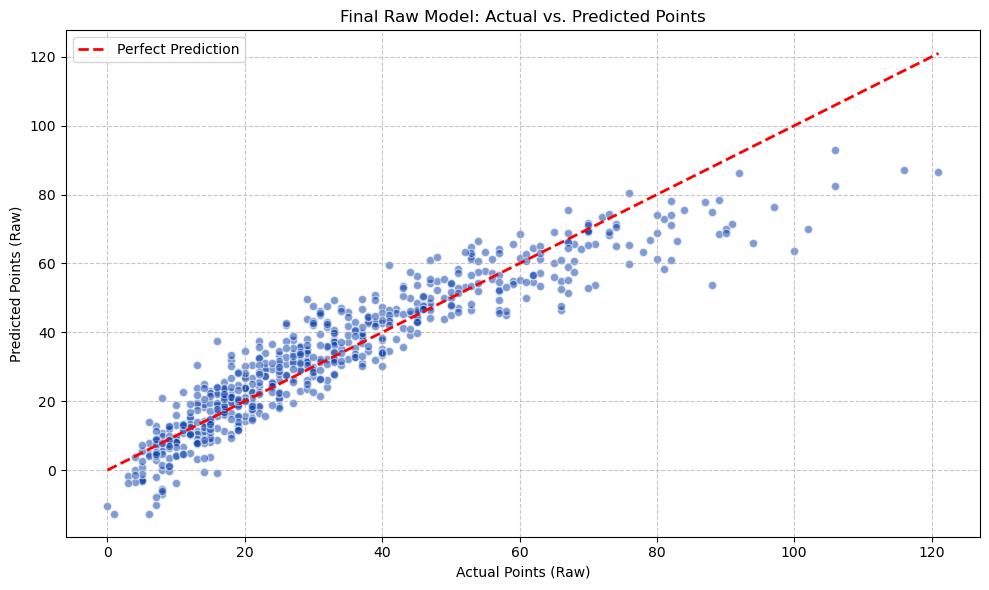

In [76]:
import statsmodels.api as sm
from sklearn.metrics import r2_score

# 1. Prepare Raw Data
X_raw = df_final[all_features].astype(float) 
y_raw = df_final['Points']

# Add constant for the intercept
X_raw_const = sm.add_constant(X_raw).to_numpy()
y_raw_vals = y_raw.values

# 2. Fit OLS with Robust Standard Errors (HC3)
ols_raw_robust = sm.OLS(y_raw_vals, X_raw_const).fit(cov_type='HC3')

# 3. Calculate Overall R-Squared
r2_val = ols_raw_robust.rsquared

# 4. Build the Results Table
# Creating a clean table with coefficients, p-values, and significance
raw_results_df = pd.DataFrame({
    'Feature': ['Intercept'] + all_features,
    'Coefficient (Raw)': ols_raw_robust.params,
    'P-Value': ols_raw_robust.pvalues
})

# Categorize features for the final output
raw_results_df['Type'] = raw_results_df['Feature'].apply(
    lambda x: 'EXPLANATORY' if x in explanatory else 'CONTROL'
)

# Apply Significance Stars
def get_stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.1: return '*'
    return ''

raw_results_df['Sig.'] = raw_results_df['P-Value'].apply(get_stars)

# 5. Display the Interpretative Results
print(f"--- FINAL INTERPRETATIVE MODEL (RAW DATA) ---")
print(f"Overall R-Squared: {r2_val:.4f}")
print("\n--- COEFFICIENTS BY CATEGORY ---")
# Sort by Type then by impact for clarity
print(raw_results_df[['Type', 'Feature', 'Coefficient (Raw)', 'P-Value', 'Sig.']].sort_values(['Type', 'Coefficient (Raw)'], ascending=[True, False]).to_string(index=False))
print("\nSignificance codes: 0 '***' 0.01 '**' 0.05 '*' 0.1 ' ' 1")

# 6. Visualization: Actual vs. Predicted (Raw Units)
plt.figure(figsize=(10, 6))
y_pred_raw = ols_raw_robust.predict(X_raw_const)

plt.scatter(y_raw_vals, y_pred_raw, alpha=0.5, color='#0038A8', edgecolors='white')
plt.plot([y_raw_vals.min(), y_raw_vals.max()], [y_raw_vals.min(), y_raw_vals.max()], 'r--', lw=2, label='Perfect Prediction')

plt.title('Final Raw Model: Actual vs. Predicted Points')
plt.xlabel('Actual Points (Raw)')
plt.ylabel('Predicted Points (Raw)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Discussing the results:

This final model provides a practical look at the scoring drivers in the NHL by using the actual units of the game rather than standardized abstractions.

1. Model Accuracy r2: Our model achieves an Overall r2 of approximately 0.87, meaning that 87% of the variance in NHL point totals is explained by our 10 selected variables.

2. Coefficient interpretation

Shot Volume: A coefficient of 0.07 for Shot_Attempts implies that for every 10 additional shots a player takes over the season, they are expected to gain roughly 0.7 points. 

Finishing Skill: A coefficient of 1.96 for Shooting_Pct_On_Unblocked means that for every 1% increase in shooting percentage, a player’s point total is expected to rise by almost 2 points.

It is also worth noting that in this model, the only statistically significant explanatory features (with 95% confidence) are:
1. Shooting_Pct_On_Unblocked
2. Giveaways
3. Shot_Attempts
4. PIM_Drawn

Step 9: Model reliability, multicollinearity and residuals

To ensure our model works as intended, we perform four diagnostic tests:

Multicollinearity: Using a correlation matrix to ensure our features aren't capturing each other's importance.

Homoskedasticity: We check the residuals (errors) against our predictions. 

Normality: We check if the models residuals are somewhat normally distributed, meaning the errors errors are random and not caused by a feature(s) missing from the model.

Autocorrelation: We perform the Durbin-Watson test to see if the residuals are autocorrlated. 

Note: The Durbin-Watson test assesses autocorrelation by calculating the sum of squared differences between each residual and the one immediately preceding it in the sequence. If the residuals are autocorrelated, these adjacent values will appear more similar (or more systematically different) than random chance allows, pushing the test statistic away from the neutral value of 2.

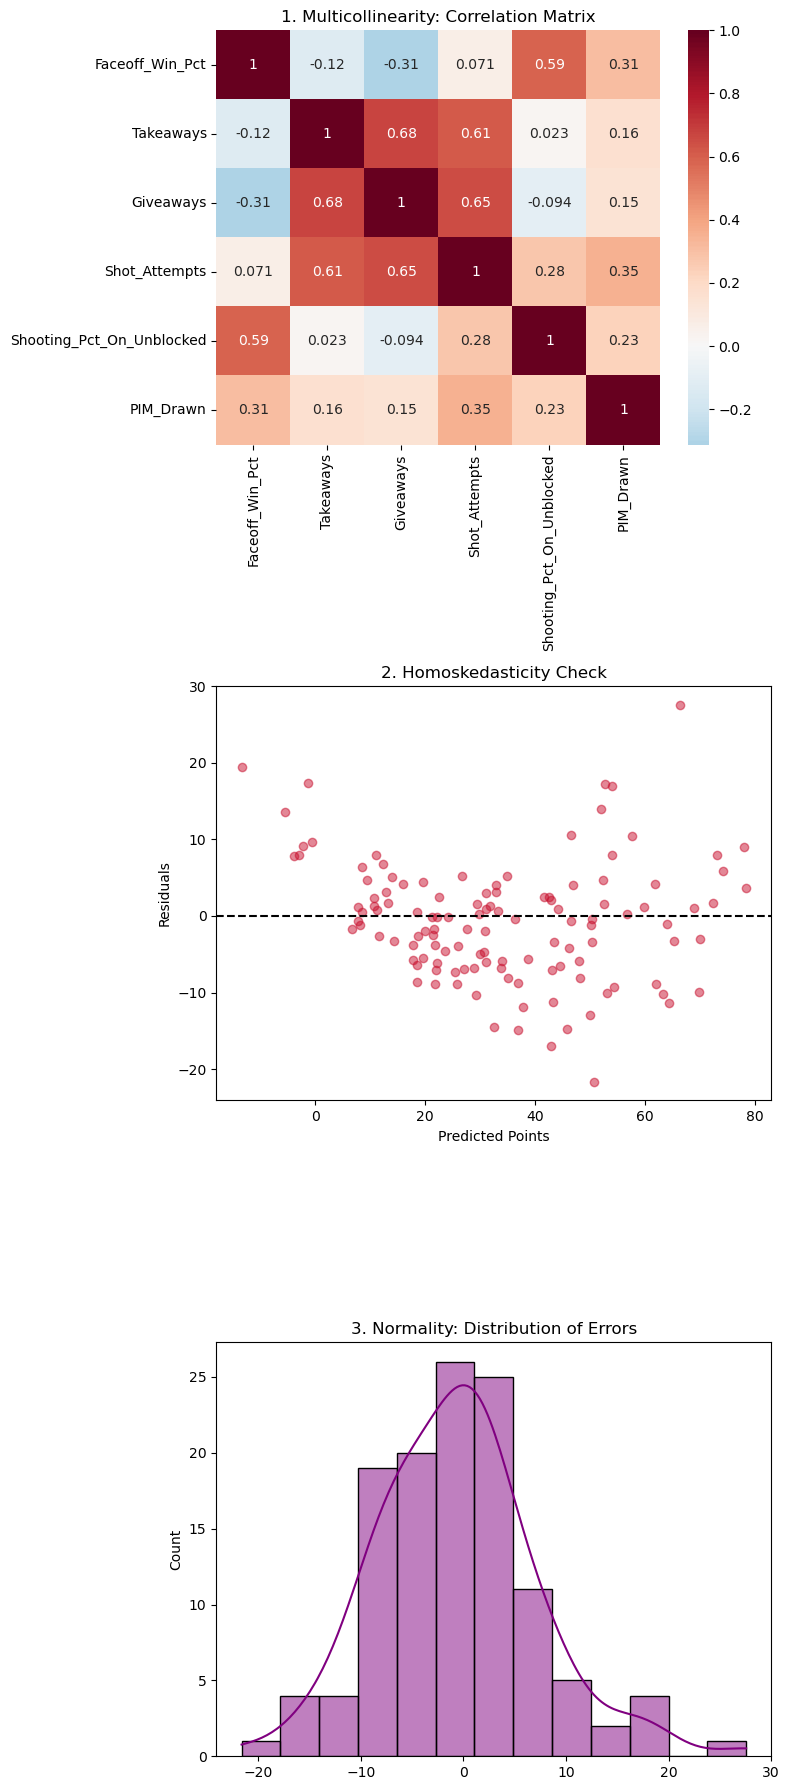

Durbin-Watson Score: 1.8392 (Values near 2.0 indicate no autocorrelation)


In [75]:
from statsmodels.stats.stattools import durbin_watson

# 1. Calculate Residuals 
ols_preds = ols_model.predict(sm.add_constant(X_test_scaled)).values
residuals = y_test.values - ols_preds

# 2. Visual Diagnostic Dashboard 
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

# Plot 1: Correlation Matrix (Independent Variables Only)
sns.heatmap(df_final[explanatory].corr(), annot=True, cmap='RdBu_r', ax=axes[0], center=0)
axes[0].set_title("1. Multicollinearity: Correlation Matrix")

# Plot 2: Homoskedasticity (Residuals vs Fitted)
axes[1].scatter(ols_preds, residuals, alpha=0.5, color='#C8102E')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title("2. Homoskedasticity Check")
axes[1].set_xlabel("Predicted Points")
axes[1].set_ylabel("Residuals")

# Plot 3: Normality Histogram
sns.histplot(residuals, kde=True, ax=axes[2], color='purple')
axes[2].set_title("3. Normality: Distribution of Errors")

plt.tight_layout()
plt.show()

# 4. Autocorrelation Check
dw_score = durbin_watson(residuals)
print(f"Durbin-Watson Score: {dw_score:.4f} (Values near 2.0 indicate no autocorrelation)")

Note: Even though the residual diagnostics indicate that our model is working roughly as intended (there might be some heteroskedasticity present), based on this analysis we cannot make the claim for a causal relationship. This is because of the methodology of this analysis and the limits of our dataset.

1. Methodology: Lasso or OLS are generally not enough to make a causal claim in themselves, even though they are often used as a part of a possibly causal analysis. For a convincing causal interpretation, we should have picked a more robust method like regression discontinuity design, difference in differences, synthetic control method or using an instrumental variable or fixed effects, all of which are outside of the scope of our ML 1 course.

2. Limits of our data: This also relates to the methodology of choice. Since we are using a regression analysis, we cannot be certain that even when using every feature in this dataset, it captures everything that makes a player to produce or not produce points. Because of this, so called "omitted variable bias" is inevitable.

Conclusions (relevant to business question)

Based on our findings, we have identified clear attributes in NHL players for identifying high-scoring talent. By isolating measurable skills from situational opportunity, we can provide the following strategic recommendations for the front office:

1. Prioritize Volume and Finishing Over "Efficiency". Some of the strongest predictors of scoring are Shot Attempts and Shooting Percentage on Unblocked Shots. To maximize points, the team should target players who possess the "Shot First" mentality and have a proven ability to hit the net from high-danger areas.

2. Engagement Players who frequently Draw Penalties (PIM Drawn) are high-value targets. These players drive play into difficult areas of the ice, forcing opponents into mistakes and creating power-play opportunities. This attribute is a reliable leading indicator of future point production, even if their current point totals are modest.

Conclusions (ML wise)

The most difficult/time consuming part was the feature selection process. Initially, we used a much larger set of features, but constantly ran into issues with multicollinearity. This is likely because all of the features at the end of the day describe on ice events and are thus heavily related. The difficult part was to select a set of features that describe different, specifc aspects of the game. 

After traditional feature selection methods (mainly Lasso and checking for multicollinearity using a correlation matrix), we filtered out a lot of features using domain knowledge, assessing what actually could have a reasonable impact the total points scored by a player. We ended up using this approach because of the previously mentioned struggles with multicollinearity, as well as the lecture slides specifically mentioning how "Regression is the analysis that helps to measure the potentially ”causal” relationship between an outcome of interest Y, and a multiple set of explanatory variables X". Because of this, it wouldn't make sense to include features that by using common sense (and domain knowledge) cannot have a direct impact on the dependent variable. 




Acknowledging AI use in this assingment

AI was used in this notebook in following ways:

1. Checking grammar mistakes in the writing of markdown cells, as well as overall making the writing in markdown cells more precise and understandable.
2. Writing some of the code, as we haven't covered in detail which libraries are needed for this kind of analysis, specifically how to use them effectively.
3. Making sure that what we do makes sense theoretically (not used in coming up with ideas on what methods to use.)